# Bayesian Networks III
# Practical Applications

This article is part of a series:

- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20I%20-%20Bayesian%20Inference.ipynb">Bayesian Inference I - Bayesian Inference</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20II%20-%20Bayesian%20Linear%20Regression.ipynb">Bayesian Inference II - Bayesian Linear Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20III%20-%20Extending%20Bayesian%20Regression.ipynb">Bayesian Inference III - Extending Bayesian Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20IV%20-%20Bayesian%20Networks%20Discrete.ipynb">Bayesian Inference IV - Discrete Bayesian Networks</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20V%20-%20Bayesian%20Networks%20Continuous%20and%20Hybrid.ipynb">Bayesian Inference V - Continuous and Hybrid Bayesian Networks</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VI%20-%20BN%20Practical%20Applications.ipynb">Bayesian Inference VI - BN Practical Applications</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VII%20-%Bayesian%20Modeling%20in%20RStan.ipynb">Bayesian Inference VII - Bayesian Modeling in RStan</a>

At the risk of seeming disorganized, this article is a bit of a mixed bag. There are a few interesting topics about Bayesian networks which did not fit neatly into the prior two articles.

1. The role of DAGs in inferring causality and conditional independence
2. Bootstrap/Averaging-based structure learning
3. Practical applications in science and industry

## Outline

<ul>
<li>Causality and Confounding</li>

</br>
<li>Conditional Independence</li>
<ul>
<li>Conditional Independence Relationship Properties</li>
</ul>

</br>
<li>Bootstrap/Average-Based Structure Learning</li>
<ul>
<li>Paper: Analysis of Class III Malocclusion Data</li>
</ul>

</br>
<li>Practical Applications</li>
<ul>
<li>Book Report: Bayesian Networks: A Practical Guide to Applications</li>
</ul>
</ul>

## Causality and Confounding

In causal analysis, DAGs are used to visualize assumptions about the causal structure of a system. Key questions they serve to answer include which variables need to be controlled (conditioned upon) to estimate causal effects, and what are potential sources of bias.

As an example of something called collider bias, consider a DAG of investment proposals that are statistically independent in terms of stability and potential return. Proposals are selected based on their strength in the two areas.

$Stability \rightarrow Chosen \leftarrow Potential$

The fact that two arrows enter 'chosen' makes it a collider. Conditioning upon a collider creates statistical, but not necessarily causal, associations among its causes. Once you learn that a proposal has been chosen, knowing that it is lacking in either stability or potential provides information about the state of the other, because if it wasn't strong in one or the either (or both), then it wouldn't have been selected.

### Confounding

Confounding is any context in which the association between outcome $Y$ and predictor $X$ is not the same as it would be, had we experimentally determined the values of $X$. Blocking all confounding paths between some predictor $X$ and some outcome $Y$ is known as shutting the backdoor. This prevents spurious correlations from sneaking in through a non-causal path. Given a causal DAG, it is possible to say which variables one must control for in order to leave the path of interest open.

There are only four types of variable relations that combine to form all possible paths.

<ol>
<li>A Fork, $X \leftarrow Z \rightarrow Y$</li>
<ul>
<li>Some variable $Z$ is a common cause of $X$ and $Y$, generating correlation between them. If we condition on $Z$, then knowing $X$ tells us nothing about $Y$. $X$ and $Y$ are independent, conditional on $Z$. We write $X \perp\!\!\!\perp Y | Z$</li>
</ul>

</br>
<li>A Pipe, $X \rightarrow Z \rightarrow Y$</li>
<ul>
<li>If a plant growth treatment $X$ influences fungus $Z$ which influences growth $Y$, if we condition on $Z$, we block the path from $X$ to $Y$. In both a fork and a pipe, conditioning on the middle variable blocks the path.</li>
</ul>

</br>
<li>A Collider, $X \rightarrow Z \leftarrow Y$</li>
<ul>
<li>In a collider, there is no relationship between $X$ and $Y$ unless you condition on $Z$. Conditioning on the collider variable $Z$ opens the path.</li>
</ul>

</br>
<li>Descendent</li>

<ul>
<li>A child in a parent-child relationship. Like conditioning on the variable itself, but weaker. A descendent $D$ is a variable influenced by another variable. $D$ will also control, to a lesser extent, for $Z$, as it holds some information about $Z$. This will partially open the path from $X$ to $Y$, because $Z$ is a collider. The same holds for non-colliders; if you condition on a descendent of $Z$ in the pipe, it'll still be like weakly closing the prior.</li>
</ul>
</ol>


## Conditional Independence

Two variables $X$ and $Y$ are conditionally independent given a third random variable $Z$ is known, knowing $X$ provides no additional information about $Y$. In the context of DAGs, conditional independence can be understood using d-separation. In a DAG, two variables $X$ and $Y$ are conditionally independent given $Z$ if, in the graph, all paths between $X$ and $Y$ are blocked when we condition on $Z$. We write:

<p>$(X \perp\!\!\!\perp Y | Z)_P \text{ if } P(x|y,z) = P(x|z)$</p>

### Conditional Independence Relationship Properties

Judea Pearl's book on Causality provides the following list of properties satisfied by conditional independence relationships.

<ol>
<li>Symmetry: $(X \perp\!\!\!\perp Y | Z) \rightarrow (Y \perp\!\!\!\perp X | Z$</li>
<ul>
<li>In any state of knowledge $Z$, if $Y$ tells us nothing new about $X$, then $X$ tells us nothing new about $Y$.</li>
</ul>

</br>
<li>Decomposition: $(X \perp\!\!\!\perp YW | Z) \rightarrow (X \perp\!\!\!\perp Y | Z)$</li>
<ul>
<li>If two combined items of information are judged irrelevant to $X$, then each separate item is irrelevant as well.</li>
</ul>

</br>
<li>Weak Union: $(X \perp\!\!\!\perp YW | Z) \rightarrow (X \perp\!\!\!\perp Y | ZW)$</li>
<ul>
<li>Learning irrelevant information $W$ cannot help the irrelevant information $Y$ become relevant to $X$.</li>
</ul>

</br>
<li>Contraction: $(X \perp\!\!\!\perp Y | Z) \text{ & } (X \perp\!\!\!\perp W | ZY) \rightarrow(X \perp\!\!\!\perp YW | Z)$</li>
<ul>
<li>If we judge $W$ irrelevant to $X$ after learning some irrelevant information $Y$, then $W$ must have been irrelevant before we learned $Y$.</li>
</ul>

</br>
<p>Together, the weak union and contraction properties mean that irrelevant information should not alter the relevance status of other propositions in the system; what was relevant remains relevant, and what was irrelevant remains irrelevant.</p>

</br>
<li>Intersection: $(X \perp\!\!\!\perp W | ZY) \text{ & } (X \perp\!\!\!\perp Y | ZW) \rightarrow (X \perp\!\!\!\perp YW | Z)$</li>
<ul>
<li>If $Y$ is irrelevant to $X$ when we know $W$ and if $W$ is irrelevant to $X$ when we know $Y$, then neither $W$ nor $Y$ (nor their combination) is relevant to $X$.</li>
</ul>

</ol>

## Bootstrap/Average-Based Structure Learning

Sometimes we don't have causal knowledge, and the object we are interested in learning is the DAG itself. Though it didn't fit nicely into the previous article, I would be remiss not to mention the capability to learn structure via bootstrapping. In other words, we can resample the data with replacement, learn a number of networks, and average over these networks by retaining only the arcs which appeared in more than a certain percentage of networks learned.

### Analysis of Class III Malocclusion Data

The paper <a href="https://doi.org/10.1038/s41598-017-15293-w">"Bayesian Networks Analysis of Malocclusion Data"</a> by M. Scutari et al. provides a great example of this, and is featured as a case study in the <code>bnlearn</code> site research notes, meaning you can get the code and the data. A malocclusion is a misalignment between the teeth of the upper and lower dental arches as the jaws close. The metrics are somewhat esoteric, if like myself, you are not in the dental or orthodontic business, but we are provided with the following definitions:

- <code>ID</code>: anonymised ID code unique to each patient.
- <code>Treatment</code>: untreated (NT), treated with bad results (TB), treated with good results (TG).
- <code>Growth</code>: a binary variable with values Good or Bad, determined on the basis of CoGn-CoA.
- <code>ANB</code>: angle between Down's points A and B (degrees).
- <code>IMPA</code>: incisor-mandibular plane angle (degrees).
- <code>PPPM</code>: palatal plane - mandibular plane angle (degrees).
- <code>CoA</code>: total maxillary length from condilion to Down's point A (mm).
- <code>GoPg</code>: length of mandibular body from gonion to pogonion (mm).
- <code>CoGo</code>: length of mandibular ramus from condilion to pogonion (mm).

Each variable has a <code>T1</code> and <code>T2</code> measurement, expressing the age of the patient at the 'before' vs. 'after' measurements. <code>T1</code> and <code>T2</code> are also available as variables themselves.

The data can be loaded from the following links:
- https://www.bnlearn.com/research/scirep17/prepd-ortho.rda
- https://www.bnlearn.com/research/scirep17/prepd-bathia.rda

First, we'll import and inspect the data.

In [ ]:
# install.packages("BiocManager")
# library("BiocManager")

# BiocManager::install("bnlearn")
# BiocManager::install("Rgraphviz")

library("bnlearn")
library("Rgraphviz")

In [2]:
load("prepd-ortho.rda")
str(ortho)

'data.frame':	143 obs. of  17 variables:
 $ ID       : Factor w/ 143 levels "P001","P002",..: 1 2 4 5 6 7 9 10 11 13 ...
 $ Treatment: Factor w/ 3 levels "NT","TB","TG": 1 1 1 1 1 1 1 1 3 1 ...
 $ Growth   : Factor w/ 2 levels "Bad","Good": 1 2 1 1 1 2 2 2 1 1 ...
 $ ANB      : num  -5.2 -1.7 -3.1 -1.3 0.4 1.5 -0.1 0.5 0.2 0.2 ...
 $ IMPA     : num  75.9 77.2 89.8 98.7 90.5 96.9 85.9 92 91.7 82.2 ...
 $ PPPM     : num  30.2 27 19.8 21.5 26.5 25.2 21.2 19.5 31.1 22.7 ...
 $ CoA      : num  83.4 91.3 78.6 96.4 83.3 88 85 77.1 88.8 77.5 ...
 $ GoPg     : num  77.9 84.1 67.3 75.6 74.7 72.8 75.2 65.2 76.2 67.8 ...
 $ CoGo     : num  50.1 59.2 50.4 65.7 51.3 58 54.9 44.8 53.3 44.5 ...
 $ ANB2     : num  -8.4 -2.3 -4.7 -2.4 -0.7 0.9 -1.3 0.4 0.8 -2.8 ...
 $ IMPA2    : num  71.7 81 83.8 86.6 83.8 95.8 87.7 93.6 92.3 82.6 ...
 $ PPPM2    : num  29.1 26.5 16.7 19.4 26.5 24.3 19.4 17.2 30.2 20.1 ...
 $ CoA2     : num  84.4 93.9 82.9 110.5 91 ...
 $ GoPg2    : num  81.9 84 71.5 96.3 83.5 71.8 76.9

In [3]:
load("prepd-bathia.rda")

Then, calculate the differences between the before and after measurements for each variable at the patient level.

In [4]:
diff = data.frame(
dANB = ortho$ANB2 - ortho$ANB,
dPPPM = ortho$PPPM2 - ortho$PPPM,
dIMPA = ortho$IMPA2 - ortho$IMPA,
dCoA = ortho$CoA2 - ortho$CoA,
dGoPg = ortho$GoPg2 - ortho$GoPg,
dCoGo = ortho$CoGo2 - ortho$CoGo,
dT = ortho$T2 - ortho$T1,
Growth = as.numeric(ortho$Growth) - 1,
Treatment = as.numeric(ortho$Treatment != "NT")
)

<code>Growth</code> and <code>Treatment</code> together carry redundant information about the prognosis, so <code>Treatment</code> is re-coded as a binary variable for which 1 means either TB (treatment with bad results) or TG (treatment with good results), and 0 means NT (no treatment). Growth is encoded such that 0 means bad and 1 means good.

The authors begin the structure learning by leveraging correlation (and domain knowledge) to determine connections and their directions. The first network learned is simply focused on nodes where correlations are greater than 40%, and does not offer directionality.

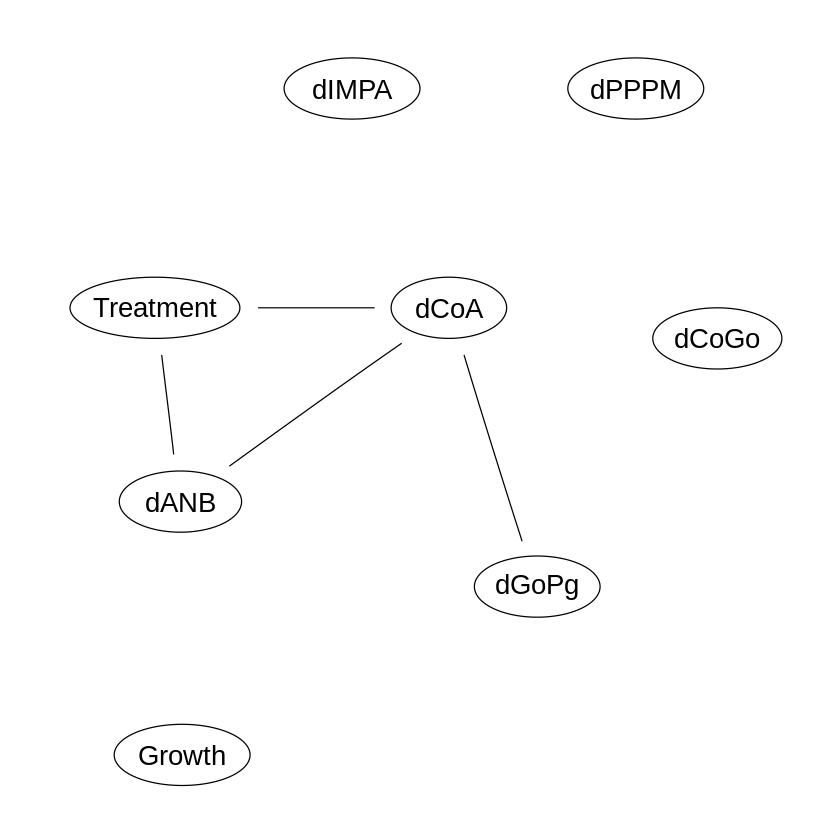

In [8]:
diff.delta = sapply(diff[, 1:6], function(x) x / diff$dT)
rho = cor(data.frame(diff.delta, Growth = diff$Growth, Treatment = diff$Treatment))
ug = empty.graph(colnames(rho))
amat(ug) = (rho > 0.4) + 0L - diag(1L, nrow(rho))
graphviz.plot(ug, layout = "fdp", shape = "ellipse")

The next network will incorporate domain knowledge through a whitelist and blacklist of connections.

-----
<ul><i>
    <li>We blacklist any arc pointing to <code>dT</code>, <code>Treatment</code> and <code>Growth</code> from the orthodontic variables.</li>
    <li>We blacklist any arc from <code>dT</code> and <code>Treatment</code>. This means that whether a patient is treated does not change over time.</li>
    <li>We whitelist the dependence structure <code>dANB</code> → <code>dIMPA</code> ← <code>dPPPM</code>.</li>
    <li>We whitelist the arc from <code>dT</code> to <code>Growth</code> which allows the prognosis to change over time.</li></i>
</ul>
<a href="https://www.bnlearn.com/research/scirep17/">https://www.bnlearn.com/research/scirep17/</a>

-----

In [9]:
bl = tiers2blacklist(list("dT", "Treatment", "Growth",
       c("dANB", "dPPPM", "dIMPA", "dCoA", "dGoPg", "dCoGo")))
bl = rbind(bl, c("dT", "Treatment"), c("Treatment", "dT"))
wl = matrix(c("dANB", "dIMPA",
              "dPPPM", "dIMPA",
              "dT", "Growth"),
        ncol = 2, byrow = TRUE, dimnames = list(NULL, c("from", "to")))

Now the bootstrapping begins. 200 networks are learned using the hill-climbing algorithm, arcs that appear at a frequency of approximately 50% or greater (this threshold is estimated from the data) are left to remain, and the <code>strength.plot</code> function is used to render a visual, highlighting whitelisted arcs with red lines.

-----
<i>"Arcs in red are constrained to be present in the network by the whitelist. The thickness of the arcs is in proportion to their strength; only arcs with strength greater than 0.5 are included in the consensus network".</i>
- Bayesian Networks Analysis of Malocclusion Data (2007)
-----

In [10]:
str.raw = boot.strength(diff, R = 200, algorithm = "hc",
            algorithm.args = list(whitelist = wl, blacklist = bl))
attr(str.raw, "threshold")
avg.raw.full = averaged.network(str.raw)

[1] 0.5

Warning message in averaged.network.backend(strength = strength, threshold = threshold):
“arc dCoGo -> dPPPM would introduce cycles in the graph, ignoring.”


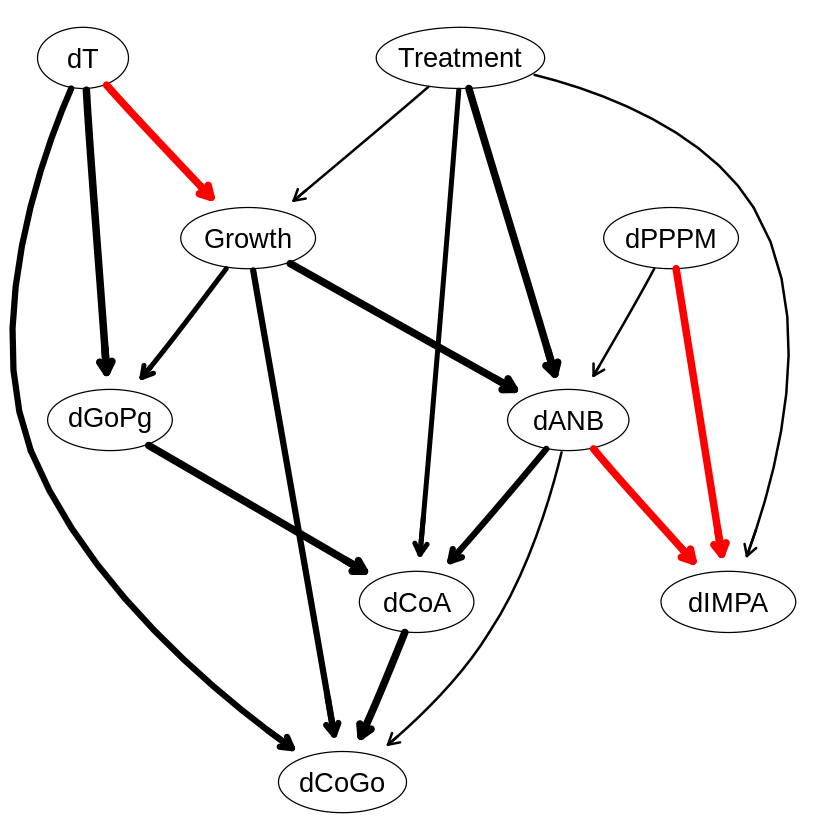

In [11]:
strength.plot(avg.raw.full, str.raw, shape = "ellipse", highlight = list(arcs = wl))

In [12]:
avg.raw.full$learning$whitelist = wl
avg.raw.full$learning$blacklist = bl

However, to work with a smaller network, the authors decide to retain arcs that appear greater than 85% of the time (or are present on the whitelist). The threshold is specified manually as follows, and the smaller network visualized.

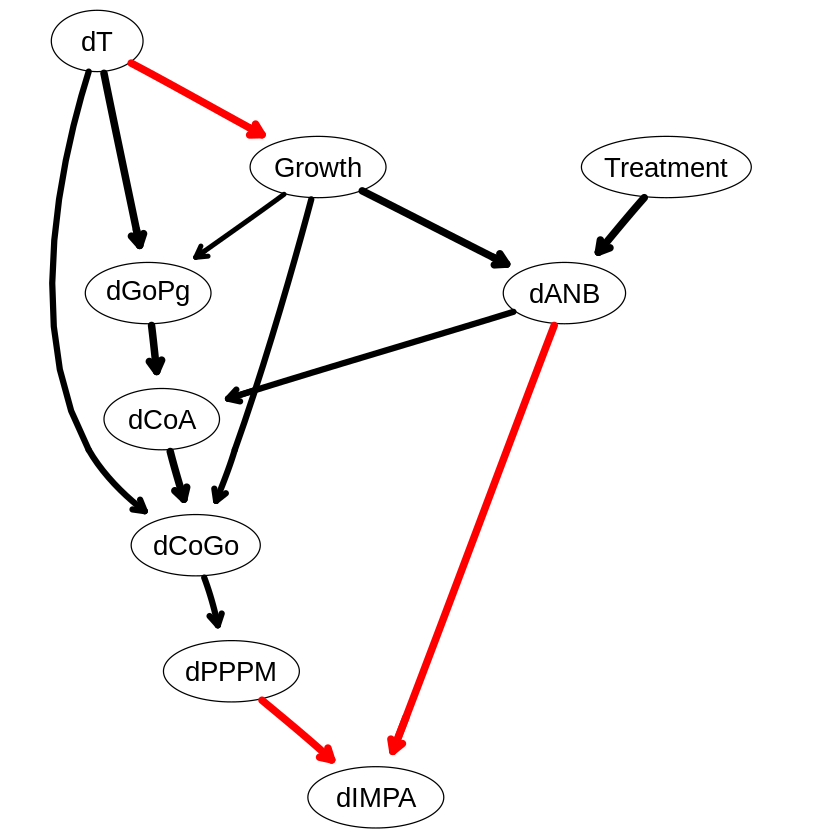

In [15]:
avg.raw.simpler = averaged.network(str.raw, threshold = 0.85)
strength.plot(avg.raw.simpler, str.raw, shape = "ellipse", highlight = list(arcs = wl))

I enourage you to peruse the <a href="https://www.bnlearn.com/research/scirep17/">vignette</a> on the <code>bnlearn</code> site, which includes a cross-validation process and findings, as well as the <a href="https://www.nature.com/articles/s41598-017-15293-w">paper</a> itself. Key insights that the authors inferred include that untreated subjects develop different class III craniofacial growth patterns compared to patients submitted to orthodontic treatment with rapid maxillary expansion and facemask therapy.

## Practical Applications

### <i>Book Report:</i>
#### <i>Bayesian Networks: A Guide to Practical Applications</i>
#### <i>Edited by Oliver Pourret, Patrick Naïm, and Bruce Marcot</i>

I found an interesting book in which the editors have compiled 20+ papers from researchers who utilized Bayesian networks within a variety of sciences and industries. It is perhaps a bit dated, as it was published in 2008 and refers to projects concluded by that time (though many mention ongoing extensions), and since then, computing power and Monte Carlo simulation has continued to improve. Without going too much into the technical details, numbers, and visuals, which you will miss out on without the book, I thought it would be interesting to summarize the settings in which these Bayesian networks were applied.

Chapters 2 through 4 focus of medical applications. The author of chapter 2 leveraged 8 years of experience applying BNs in medicine to establish a BN-based system of diagnosing liver disease called HEPARII. The structure of the model was based on the judgment of experts in the domain, who were found to rarely disagree. Each case was described by over 160 medical findings, such as self-reported data (for which uncertainty accounts for unreliability), physical examinations, etc. HEPARII started out as a single-disorder model, but was found to be more valuable as a multi-disorder model. The reaction from users was very positive, and many expressed having learned from the model.

In chapter 3, the authors document implementation of a system called TakeHeartII for the clinical assessment of coronary disease risk, based on lifestyle factors and physical characteristics such as age, blood pressure, and cholesterol. Chapter 4 features genetic research, in which the authors use BNs to discover complex genetic traits; i.e., non-deterministic predispositions toward diseases such as diabetes, dementia, and cardiovascular disease that are known to be cause by an interaction between genes (perhaps multiple) and the environment. That model was successfully used to analyze macular degeneration, stroke risk in sickle cell anemia patients, and factors related to exceptional lifespan.

Chapters 5, 7, and 14 focus on crime and defense. In chapter 5, the author writes about a pilot scheme to analyze crime rates in the Bangkok metropolitan area. Officers found it difficult to express their beliefs quantitatively, so a formal elicitation process found in literature was utilized. The data consisted of 20 variables grouped into categories of population, crime location, type of crime, traffic, and environment. This led to a variety of insights and the author expressed a desire to extend BN-type modeling toward a broader range of criminal statistics, as well as road accidents.

In chapter 7, Swiss authors seek to leverage a BN for forensic science, to draw inference about happenings in the past for the sake of assisting investigative and legal proceedings. Historically, difficulties had arisen with other probabilistic models when one needed to cope with multiple sources of uncertainty (and possibly complicated interrelated structure), multiple items of evidence, and situations involving a lack of data.

<i>"The reported works jointly support the idea that graphical probability models can substantially improve the evaluation of likelihood ratios used for assessment of scientific evidence. They allow the user to engage in probabilistic analyses of much higher complexity than what would be possible through traditional approaches that rely on rigid, purely arithmetic developments. The graphical nature also facilitates the formal discussion and classification of probabilistic arguments."</i>

In chapter 14, US-based authors describe their utilization of BNs to create a system for terrorism-risk analysis. An alphabet-soup of prior systems were in existence, but it was concluded that incremental updates to the existing systems would not be satisfactory. The system, called Site Profiler, was deployed in environments with up to 5000 assets and 19 threat types.

Chapters 6, 8, and 9 involve land-use, but from the perspectives of socio-demographics, conservation, and mineral potential respectively. In chapter 6, the author, an associate professor of Geology in France, describes modeling socio-demographic and urban spatial dynamics in the south-Eastern coastal region, with geographic data and data provided by the two most recent censuses. A number of elements at the municipal level were measured, including population dynamics, housing, land-use dynamics, transportation, and population mobility. Variable categories included site (e.g. distance from shore), situation (e.g. distance to closest highway), spatial interaction (e.g. accessible jobs within 30 minutes of travel), employment (e.g. number of jobs per resident), household (e.g. average household size), mobility (e.g. share of commuters), and land use (e.g. relative size of new urbanization over time). The author noted that the network simplified the complexity of causal inference among variables, and that by highlighting the most statistically significant links, it allowed for a cleaner view of the mean spatial phenomenon.

In chapter 8, a British Columbia based author describes the conservation efforts toward marbled murrelets, a threatened sea-bird which spends most of its life at sea, but nests in the forests on old-growth trees. The models were used to model abundance and viability at alternative nesting habitats, or alternatively, the amount and characteristics of habitat consistent with desired population and viability targets. Reasons for choosing a BN model included:
- Explicit consideration of the logic and assumptions in the ecological system.
- Means of combining field data, literature, and expert opinion.
- Incorporation of uncertainty.
- Useful functionality for sensitivity analyses, model updating from case data, including reverse findings, and processing of management scenarios as case data generated by other types of models.

The research team applied the 'bet hedging' approach to combine estimates from multiple subpopulations into a coast-wide joint persistence probability.

Chapter 9 involves the assessment of mineral potential in areas of a province in India, enabling policy makers to estimate the socio-economic benefits from different land-use types and allocate suitable land-use. Each unit cell of land was evaluated as barren or mineralized, and the BN classifiers successfully demonstrated favorable zones that occupied 7-11% of the area, and contain 83-93% of the known base metal deposits.

There are 11 other chapters which I'll just touch upon at the topic level. Business applications include company credit rating, corporate default risk, and wine classification. Industrial and engineering applications include sensor validation, pavement and bridge management, industrial process operation, and risk management in robotics. Educational and cognitive applications include student modeling (for a tutoring system), and enhancing human cognition. Miscellaneous applications include the retrieval of parliamentary documents, and the general use of dynamic BNs for time-series problems.

Hopefully that adds some color, and is somewhat inspiring. 

The next article will involve creating a general Bayesian network (and Bayesian programming in R in general) using the <code>rstan</code> package for the C++ sampler <code>stan</code>.

## References

- McElreath, R. (2020). Statistical Rethinking (2nd ed.). CRC Press.

- [Richard McElreath]. Statistical Rethinking 2023 Lectures [Video]. Youtube. https://www.youtube.com/watch?v=FdnMWdICdRs&list=PLDcUM9US4XdPz-KxHM4XHt7uUVGWWVSus

- Scutari, M., Auconi, P., Caldarelli, G., & Franchi, L. (2017). Bayesian Networks Analysis of Malocclusion Data. Nature. https://doi.org/10.1038/s41598-017-15293-w

- bnlearn (n.d.). Analysis of class III malocclusion in Scutari et al., Scientific Reports (2017). Bnlearn Documentation. https://www.bnlearn.com/research/scirep17/

- Pourret, O., Naim, P., & Marcot, B. (2008). Bayesian Networks: A Practical Guide to Applications (1st ed.). Wiley. https://www.wiley.com/en-ca/Bayesian+Networks%3A+A+Practical+Guide+to+Applications-p-9780470994542